# 🛠️ Preparación de los Datos

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
#Extraemos datos tratados
df=pd.read_csv('datos_tratados.csv')
df

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,No,Female,No,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,9992-RRAMN,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,9992-UJOEL,No,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,9993-LHIEB,No,Male,No,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


In [59]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [61]:
#Eliminamos las columnas irrelevantes
df = df.drop('CustomerID', axis=1)
df

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,No,No,No,13,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


In [62]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No'})

df[cols_to_fix]

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,No,Yes,No,Yes,Yes,No
1,No,No,No,No,No,Yes
2,No,No,Yes,No,No,No
3,No,Yes,Yes,No,Yes,Yes
4,No,No,No,Yes,Yes,No
...,...,...,...,...,...,...
7038,Yes,No,No,Yes,No,No
7039,No,No,No,No,No,Yes
7040,No,Yes,No,No,No,No
7041,Yes,No,Yes,Yes,No,Yes


In [63]:
for col in df.columns:
  if df[col].nunique() <= 10:
    unique_values = df[col].unique()
    print("-"*50)
    print(f"Valores únicos en la columna '{col}': {unique_values}")
  else:
    print("-"*50)
    print(f"La columna '{col}' tiene {df[col].nunique()} valores únicos")

--------------------------------------------------
Valores únicos en la columna 'Churn': ['No' 'Yes']
--------------------------------------------------
Valores únicos en la columna 'Gender': ['Female' 'Male']
--------------------------------------------------
Valores únicos en la columna 'SeniorCitizen': ['No' 'Yes']
--------------------------------------------------
Valores únicos en la columna 'Partner': ['Yes' 'No']
--------------------------------------------------
Valores únicos en la columna 'Dependents': ['Yes' 'No']
--------------------------------------------------
La columna 'Tenure' tiene 73 valores únicos
--------------------------------------------------
Valores únicos en la columna 'PhoneService': ['Yes' 'No']
--------------------------------------------------
Valores únicos en la columna 'MultipleLines': ['No' 'Yes']
--------------------------------------------------
Valores únicos en la columna 'InternetService': ['DSL' 'Fiber optic' 'No']
-----------------------------

In [64]:
df.isnull().sum()

Churn               0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
ChargesDaily        0
ChargesMonthly      0
ChargesTotal        0
dtype: int64

In [65]:
df.isna().sum()

Churn               0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
ChargesDaily        0
ChargesMonthly      0
ChargesTotal        0
dtype: int64

In [66]:
df.describe()

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,2.158675,64.761692,2279.734304
std,24.559481,1.003088,30.090047,2266.794470
min,0.000000,0.610000,18.250000,0.000000
25%,9.000000,1.180000,35.500000,398.550000
50%,29.000000,2.340000,70.350000,1394.550000
75%,55.000000,2.990000,89.850000,3786.600000
max,72.000000,3.960000,118.750000,8684.800000


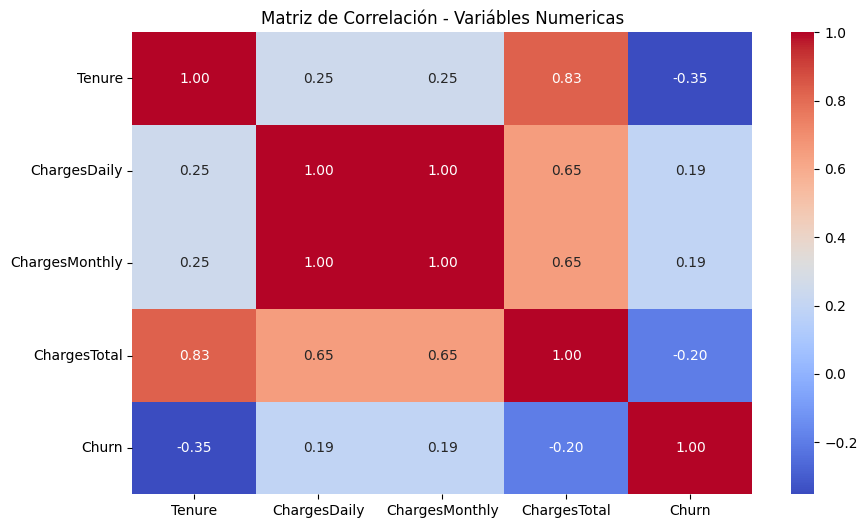

In [67]:
df_numeric = df.select_dtypes(include=["int64", "float64"])
df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
corr_matrix = df_numeric.corr()

#Visualización
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()

In [68]:
#Eliminamos columnas
df = df.drop(columns=["ChargesDaily","ChargesTotal"])
df

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,No,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7039,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7040,No,Male,No,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


In [69]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

df_rank = df.copy()

df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

categorical_cols = df_rank.select_dtypes(include=["object"]).columns

le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

chi_scores, p_values = chi2(X_cat, y)

chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df

,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [70]:
significant_vars = chi_df[chi_df["p-value"] < 0.05]

print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)


✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [71]:
df = df.drop(columns=["Gender", "PhoneService"])
df

,Churn,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,No,Yes,Yes,9,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,No,No,No,No,9,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,Yes,No,No,No,4,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,Yes,Yes,Yes,No,13,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,Yes,Yes,Yes,No,3,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,No,No,No,13,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7039,Yes,No,Yes,No,22,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7040,No,No,No,No,2,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7041,No,No,Yes,Yes,67,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


In [72]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
    )
     

In [73]:
print(X_train.shape)
print(X_train_norm.shape)

(5634, 16)
(5634, 20)


In [74]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3793 to 5679
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     5634 non-null   object 
 1   Partner           5634 non-null   object 
 2   Dependents        5634 non-null   object 
 3   Tenure            5634 non-null   int64  
 4   MultipleLines     5634 non-null   object 
 5   InternetService   5634 non-null   object 
 6   OnlineSecurity    5634 non-null   object 
 7   OnlineBackup      5634 non-null   object 
 8   DeviceProtection  5634 non-null   object 
 9   TechSupport       5634 non-null   object 
 10  StreamingTV       5634 non-null   object 
 11  StreamingMovies   5634 non-null   object 
 12  Contract          5634 non-null   object 
 13  PaperlessBilling  5634 non-null   object 
 14  PaymentMethod     5634 non-null   object 
 15  ChargesMonthly    5634 non-null   float64
dtypes: float64(1), int64(1), object(14)
memory u

In [75]:
#Verificación de la Proporción de Cancelación (Churn)
resumen_balance = (y_train.value_counts(normalize=True) * 100).to_frame(name='Proporción (%)')
display(resumen_balance.style.format("{:.2f}%"))

,Proporción (%)
Churn,
No,73.46%
Yes,26.54%


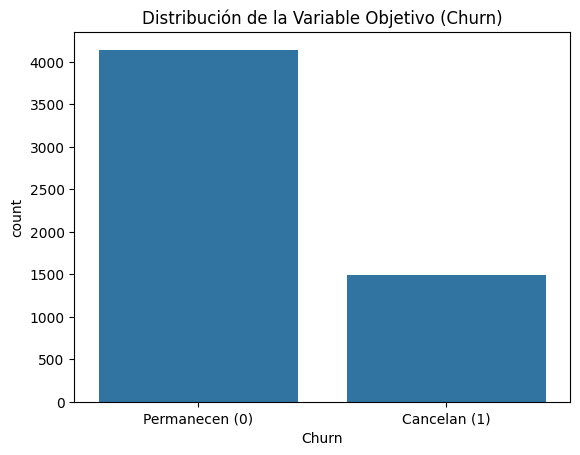

In [76]:
sns.countplot(x=y_train)
plt.title('Distribución de la Variable Objetivo (Churn)')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelan (1)'])
plt.show()

In [77]:
#Normalización o Estandarización
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

col_numeric = df.select_dtypes(include=["int64", "float64"]).columns
col_numeric     

Index(['Tenure', 'ChargesMonthly'], dtype='object')

In [78]:
scaler = MinMaxScaler()

X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

X_train_norm[col_numeric] = scaler.fit_transform(X_train[col_numeric])
X_test_norm[col_numeric] = scaler.transform(X_test[col_numeric])

X_train_norm[col_numeric].describe()

,Tenure,ChargesMonthly
count,5634.000000,5634.000000
mean,0.449301,0.464700
std,0.341426,0.299184
min,0.000000,0.000000
25%,0.125000,0.198430
50%,0.402778,0.519432
75%,0.763889,0.712506
max,1.000000,1.000000


In [79]:
#Encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_train_norm = pd.get_dummies(X_train_norm, drop_first=True)

# Aplicar en datos de prueba

X_test = pd.get_dummies(X_test, drop_first=True)
X_test_norm = pd.get_dummies(X_test_norm, drop_first=True)

# Asegurar que entrenamiento y prueba tengan las mismas columnas

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
X_train_norm, X_test_norm = X_train_norm.align(X_test_norm, join='left', axis=1, fill_value=0)

X_train.head()

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,94.10,False,True,False,True,True,False,True,True,False,False,False,True,False,False,True,True,False,False
3192,12,19.35,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4922,2,80.45,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False
3926,33,74.75,False,True,True,False,False,False,True,False,True,False,True,True,True,False,False,True,False,False
3859,14,86.00,False,False,True,True,True,False,True,False,False,True,False,False,False,False,True,False,False,True


# 🎯 Correlación y Selección de Variables

In [80]:
temp_df = X_train.copy()
temp_df['Churn'] = y_train.map({'Yes': 1, 'No': 0})

plt.figure(figsize=(12, 8))
correlation = temp_df.corr()

correlation['Churn']

Tenure                                  -0.351948
ChargesMonthly                           0.188884
SeniorCitizen_Yes                        0.153134
Partner_Yes                             -0.152032
Dependents_Yes                          -0.158042
MultipleLines_Yes                        0.042973
InternetService_Fiber optic              0.303902
InternetService_No                      -0.225631
OnlineSecurity_Yes                      -0.168577
OnlineBackup_Yes                        -0.086360
DeviceProtection_Yes                    -0.067663
TechSupport_Yes                         -0.171160
StreamingTV_Yes                          0.067602
StreamingMovies_Yes                      0.051428
Contract_One year                       -0.180497
Contract_Two year                       -0.302556
PaperlessBilling_Yes                     0.192693
PaymentMethod_Credit card (automatic)   -0.129420
PaymentMethod_Electronic check           0.304426
PaymentMethod_Mailed check              -0.089693


<Figure size 1200x800 with 0 Axes>

In [81]:
temp_df[temp_df['Churn']==1].describe()

,Tenure,ChargesMonthly,Churn
count,1495.000000,1495.000000,1495.0
mean,17.955184,74.467659,1.0
std,19.536154,24.518907,0.0
min,1.000000,18.850000,1.0
25%,2.000000,56.675000,1.0
50%,10.000000,79.600000,1.0
75%,29.000000,94.200000,1.0
max,72.000000,118.350000,1.0


In [82]:
#Modelo 1: Regresión Logísitca
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

log_model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')

log_model_balanced.fit(X_train_norm, y_train)

y_pred_log_bal = log_model_balanced.predict(X_test_norm)

print("--- REGRESIÓN LOGÍSTICA ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_bal):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_log_bal))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_log_bal))

--- REGRESIÓN LOGÍSTICA ---
Accuracy: 0.7445

Matriz de Confusión:
[[753 282]
 [ 78 296]]

Reporte de Clasificación:
              precision    recall  f1-score   support

          No       0.91      0.73      0.81      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [83]:
#Modelo 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("--- RANDOM FOREST (Datos Originales) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

--- RANDOM FOREST (Datos Originales) ---
Accuracy: 0.7764

Matriz de Confusión:
[[816 219]
 [ 96 278]]

Reporte de Clasificación:
              precision    recall  f1-score   support

          No       0.89      0.79      0.84      1035
         Yes       0.56      0.74      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409



# 📋 Interpretación y Conclusiones

In [84]:
rf_importances = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

log_coeffs = pd.DataFrame({
    'Variable': X_train.columns,
    'Impacto': log_model_balanced.coef_[0]
}).sort_values(by='Impacto', ascending=False)


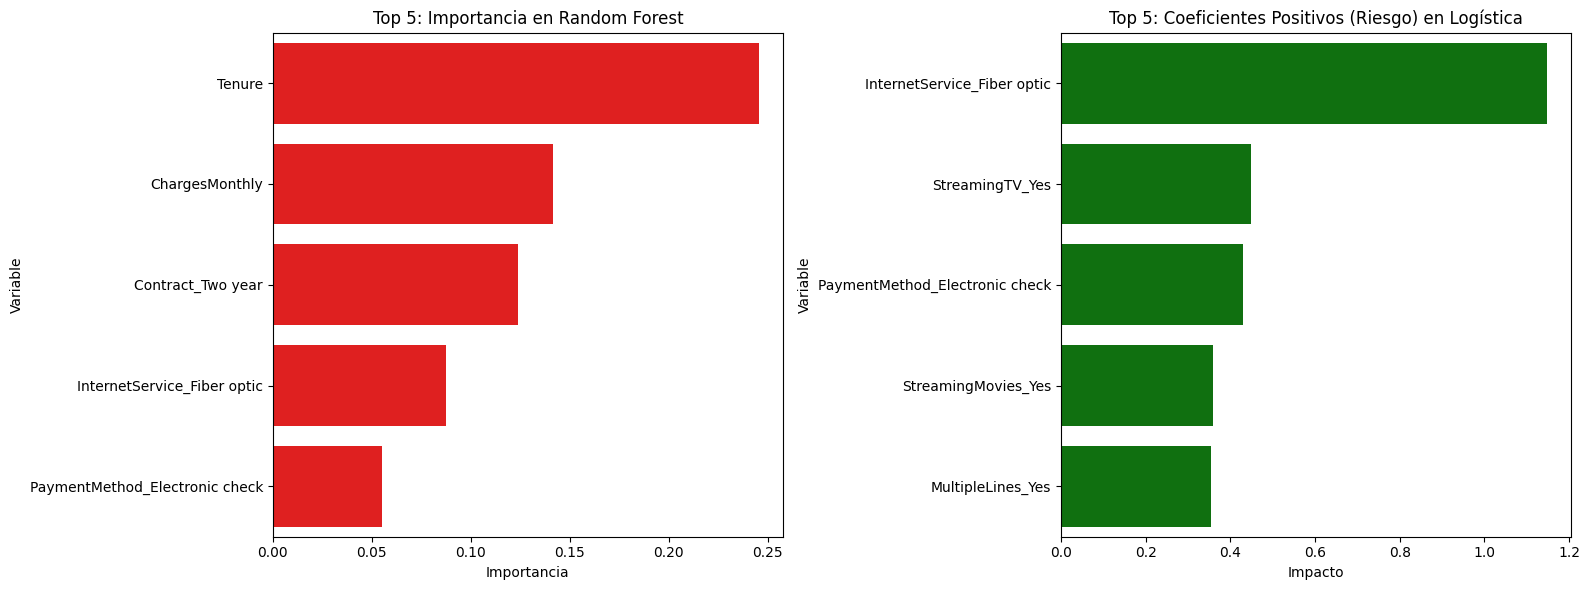

In [85]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Importancia', y='Variable', data=rf_importances.head(5), ax=ax[0], color='red')
ax[0].set_title('Top 5: Importancia en Random Forest')

sns.barplot(x='Impacto', y='Variable', data=log_coeffs.head(5), ax=ax[1], color = 'green')
ax[1].set_title('Top 5: Coeficientes Positivos (Riesgo) en Logística')

plt.tight_layout()
plt.show()

# Conlusión  

**Rendimiento de los modelos**  
1. Regresión lógistica (Balanceada)
    * Precisión Global (Accuracy): 74.45%
    * Sensibilidad (Recall) para Churn: 79%
    * F1-Score para Churn: 0.62  
    * Nota: Este modelo demostró ser excelente para la prevención, ya que logra identificar de forma correcta al 79% de los clientes que efectivamente van a cancelar, minimizando los "falsos negativos" (clientes que se van sin que el modelo lo advierta).

2. Random Forest
    * Precisión Global (Accuracy): 77.64%
    * Sensibilidad (Recall) para Churn: 74%
    * F1-Score para Churn: 0.64
    * Nota: Este modelo ofrece el mejor equilibrio general y es el más preciso para entender la jerarquía (importancia) de las variables no lineales.

**Factores Principales que Influyen en la Cancelación**  
Los principales factores que influyen en la cancelación de clientes están fuertemente ligados al nivel de compromiso y al valor percibido del servicio. El mayor riesgo de abandono se observa en clientes con contratos mensuales y poca antigüedad, quienes son altamente vulnerables durante sus primeros meses. A esto se suma la sensibilidad a los costos, ya que las facturas elevadas incrementan drásticamente la probabilidad de fuga. Por otro lado, la adopción de servicios de valor agregado, como el soporte técnico y la seguridad en línea, actúa como un fuerte escudo de retención. Finalmente, la forma en que el cliente interactúa administrativamente con la empresa también influye, siendo la facturación electrónica sin papel y ciertos métodos de pago manuales factores que facilitan ligeramente la decisión de cancelar el servicio.

**Estrategias de Retención Propuestas**  
1. Programa de migración de contratos: Como el principal impulsor de churn es el contrato mensual, se debe diseñar una campaña ofensiva para convertir a estos usuarios a planes de uno o dos años.
2. Flexibilidad en precios y paquetes: El modelo de Regresión Logística penaliza fuertemente a los cargos totales mensuales.
3. Anclar a los clientes con servicios adicionales: El soporte técnico (TechSupport) y la seguridad online (OnlineSecurity) demostraron reducir el churn
4. Enfoque especializado de "Onboarding" (primeros 6 Meses): Dado que la variable Tenure es crítica, la atención no debe ser igual para todos. El riesgo es más alto al principio.
5. Uso Activo del Modelo de Prevención: Implementar de inmediato el modelo de Regresión Logística dentro de los sistemas de la empresa. Al final de cada mes, se debe correr para obtener el grupo de clientes con mayor probabilidad de cancelación.